**RAA: DEEP LEARNING: PARTE 2**

Empezamos con la importacion de todas las libreriass y fubnciones necesarias para todo el pipline

In [1]:
import math
import os
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from PIL import Image
from tqdm.auto import tqdm

from google.colab import drive
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accedemos a la ruta donde tenemos cargadas nuestras imágenes en Google Drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive



##PREPROCESAMIENTO:
Empezamos definiendo la clase encargada de hacer el preprocesamiento de las imágenes:

In [3]:
class BearingDataset(Dataset):
    def __init__(self, root_dir, image_size=256):
        self.root_dir = Path(root_dir)
        self.image_size = image_size

        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        self.image_paths = list(self.root_dir.glob("*.jpg"))
        print("Imágenes encontradas:", len(self.image_paths))

        if len(self.image_paths) == 0:
            raise ValueError(f"No se encontraron imágenes en {self.root_dir}")

    def create_ring_mask(self, image, inner_radius=120, outer_radius=250):

        img_np = np.array(image)

        h, w = img_np.shape[:2]
        center_x, center_y = w // 2, h // 2

        # Coordenadas
        Y, X = np.ogrid[:h, :w]

        # Distancia al centro
        dist_from_center = np.sqrt(
            (X - center_x) ** 2 + (Y - center_y) ** 2
        )

        # Máscara del anillo
        mask = (
            (dist_from_center >= inner_radius) &
            (dist_from_center <= outer_radius)
        )

        # Aplicar máscara
        masked = np.zeros_like(img_np)
        masked[mask] = img_np[mask]

        return Image.fromarray(masked)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path).convert("RGB")
        image = image.crop((285, 225, 950, 900))  # crop específico
        image = self.create_ring_mask(
            image,
            inner_radius=185,
            outer_radius=320
        )
        image = self.transform(image)
        return image, str(path)

antes de realizar el preprcesamiento de todas las imágenes del dataset, mostramos el efecto de este en una sola imágen:

Imágenes encontradas: 6504

IMAGEN ORIGINAL
Tamaño: (1244, 1244)
Modo: L

IMAGEN PREPROCESADA
Shape tensor: torch.Size([3, 259, 256])


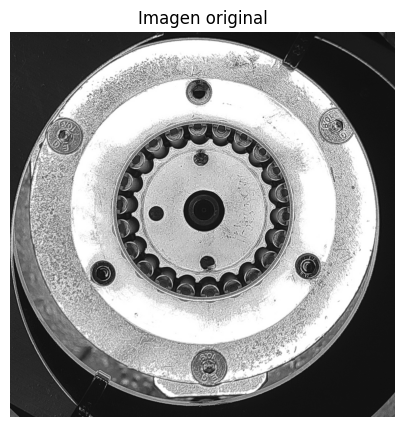

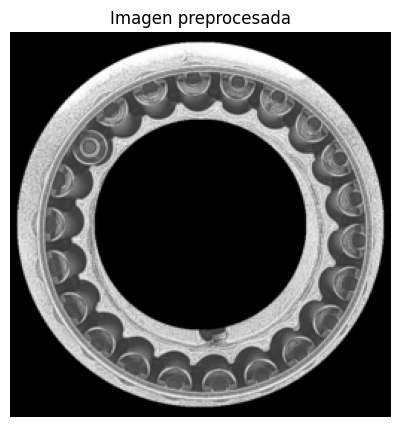

In [4]:
INPUT_DIR = "/content/drive/MyDrive/datasets/Train_bearing_images"
OUTPUT_DIR = "/content/drive/MyDrive/datasets/TrainBearingPreprocess"

dataset = BearingDataset(root_dir=INPUT_DIR, image_size=256)

#para hacer una idea de cómo funciona el preprocesamiento mostramoso una imagen del dataset antes y despues
raw_path = dataset.image_paths[10]
raw_image = Image.open(raw_path)

print("\nIMAGEN ORIGINAL")
print("Tamaño:", raw_image.size)
print("Modo:", raw_image.mode)

plt.figure(figsize=(5,5))
plt.imshow(raw_image, cmap='gray')
plt.title("Imagen original")
plt.axis("off")

processed_image, path = dataset[0]

print("\nIMAGEN PREPROCESADA")
print("Shape tensor:", processed_image.shape)

# Revertimos la nomaliazcion del tensor para poder mostrar la imagen
img = processed_image.numpy().transpose((1, 2, 0))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = std * img + mean
img = np.clip(img, 0, 1)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Imagen preprocesada")
plt.axis("off")

plt.show()

A continuación, definimos el modelo de entrenamiento que vamos a usar



##DEFINICIÓN DEL MODELO:

Ahora definimos el modelo preentrenado que se va a usar, en este caso será WideResNet50, entrenado sobre el dataset ImageNet

In [5]:
class WideResNet50FeatureExtractor(nn.Module):

    def __init__(self, unfreeze_last_layer=True):
        super().__init__()
        backbone = models.wide_resnet50_2(
            weights=models.Wide_ResNet50_2_Weights.DEFAULT
        )


        self.stem = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool
        )

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3

        # congelamos todos los pesos
        for param in self.parameters():
            param.requires_grad = False

        #dejamos descongelada la última capa, para hacer fine-turing
        if unfreeze_last_layer:
            for param in self.layer3.parameters():
                param.requires_grad = True

    def forward(self, x):
        x = self.stem(x)
        f1 = self.layer1(x)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)
        return [f1, f2, f3]

A continucación , se define la clase FeatureAdapter, cuya función es adaptar las características extraídas por un modelo preentrenado antes de ser procesadas por el modelo de flujo.

Para ello, utiliza una combinación de convoluciones (1×1 y 3×3), seguidas de normalización (Batch Normalization) y funciones de activación (ReLU), lo que permite mejorar la estabilidad y la capacidad de representación de las características.

In [6]:
class FeatureAdapter(nn.Module):

    def __init__(self, in_channels, hidden_channels=None, out_channels=None):
        super().__init__()
        hidden_channels = hidden_channels or in_channels
        out_channels = out_channels or in_channels


        self.adapter = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.adapter(x)

Seguimos con la definición de todos los bloque fundamentales de las componentes de nuestro modelo:

La clase ConvSubNet define una pequeña red convolucional cuya función es predecir los parámetros de escala (s) y traslación (t) a partir de una parte de la entrada. La última capa se inicializa a cero para estabilizar el entrenamiento al inicio.

La clase Invertible1x1Conv implementa una convolución 1x1 invertible, cuya función es mezclar los canales de la entrada de manera reversible. Se inicializa como una matriz ortogonal para garantizar su invertibilidad y permite calcular eficientemente el determinante del jacobiano, necesario para el entrenamiento basado en máxima verosimilitud.

Por último, la clase AffineCoupling define una capa de acoplamiento afín, que divide los canales de la entrada en dos partes. Una de ellas se mantiene fija, mientras que la otra se transforma mediante una operación afín cuyos parámetros son generados por la subred convolucional. Este bloque es clave, ya que permite construir transformaciones complejas manteniendo la invertibilidad y facilitando el cálculo del jacobiano.

In [7]:
class ConvSubNet(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, in_channels * 2, kernel_size=3, padding=1)
        )

        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)


class Invertible1x1Conv(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        w_init = torch.linalg.qr(torch.randn(num_channels, num_channels)).Q
        self.weight = nn.Parameter(w_init)

    def forward(self, x):
        B, C, H, W = x.shape
        weight = self.weight.view(C, C, 1, 1)
        z = F.conv2d(x, weight)
        logdet = H * W * torch.slogdet(self.weight)[1]
        return z, logdet

    def inverse(self, z):
        C = z.shape[1]
        w_inv = torch.inverse(self.weight).view(C, C, 1, 1)
        return F.conv2d(z, w_inv)



class AffineCoupling(nn.Module):
    def __init__(self, channels, hidden_channels=128):
        super().__init__()
        if channels % 2 != 0:
            raise ValueError("El número de canales debe ser par.")
        self.half_channels = channels // 2
        self.nn_scale_shift = ConvSubNet(self.half_channels, hidden_channels)

    def forward(self, x):
        x_a, x_b = torch.chunk(x, 2, dim=1)
        h = self.nn_scale_shift(x_a)
        s, t = torch.chunk(h, 2, dim=1)
        s = torch.tanh(s)
        z_b = x_b * torch.exp(s) + t
        z = torch.cat([x_a, z_b], dim=1)
        logdet = torch.sum(s, dim=(1, 2, 3))
        return z, logdet

    def inverse(self, z):
        z_a, z_b = torch.chunk(z, 2, dim=1)
        h = self.nn_scale_shift(z_a)
        s, t = torch.chunk(h, 2, dim=1)
        s = torch.tanh(s)
        x_b = (z_b - t) * torch.exp(-s)
        return torch.cat([z_a, x_b], dim=1)

En la siguiente celda se definen los bloques que componen el flujo normalizante. La clase FlowStep representa un paso del flujo, combinando una convolución 1×1 invertible y una capa de acoplamiento afín, permitiendo transformar las características de forma reversible y calcular el log-determinante del Jacobiano.

Por su parte, FlowBranch agrupa varios de estos pasos de manera secuencial, formando una cadena de transformaciones más compleja. Durante el forward, aplica cada paso acumulando el log-determinante total, necesario para el cálculo de la función de pérdida en el entrenamiento.

In [8]:
class FlowStep(nn.Module):
    def __init__(self, channels, hidden_channels=128):
        super().__init__()
        self.invconv = Invertible1x1Conv(channels)
        self.coupling = AffineCoupling(channels, hidden_channels)


    def forward(self, x):
        x, logdet1 = self.invconv(x)
        x, logdet2 = self.coupling(x)
        if isinstance(logdet1, torch.Tensor) and logdet1.dim() == 0:
            logdet1 = logdet1.expand(x.shape[0])
        return x, logdet1 + logdet2


    def inverse(self, z):
        z = self.coupling.inverse(z)
        return self.invconv.inverse(z)


class FlowBranch(nn.Module):
    def __init__(self, channels, num_steps=8, hidden_channels=128):
        super().__init__()
        self.steps = nn.ModuleList([
            FlowStep(channels, hidden_channels) for _ in range(num_steps)
        ])


    def forward(self, x):
        total_logdet = torch.zeros(x.shape[0], device=x.device)
        for step in self.steps:
            x, logdet = step(x)
            total_logdet += logdet
        return x, total_logdet


Por último, se define la arquitectura completa del modelo FastFlow. El modelo combina un extractor de características preentrenado, varios módulos adaptadores y múltiples ramas de flujo normalizante aplicadas a diferentes niveles de características.

Cada mapa de características extraído es primero adaptado mediante un FeatureAdapter y posteriormente transformado por un FlowBranch, que modela su distribución mediante normalizing flows. La función forward calcula la probabilidad logarítmica de las variables latentes bajo una distribución gaussiana y la combina con el log-determinante del flujo para obtener la verosimilitud de los datos.

Finalmente, la pérdida se calcula sumando las pérdidas de log-verosimilitud negativa obtenidas en cada rama de características, lo que permite entrenar el modelo para detectar anomalías.

In [9]:
class FastFlow(nn.Module):
    def __init__(
        self,
        flow_steps=6,
        flow_hidden_channels=256,
        adapter_hidden_channels=(256, 512, 1024),
        unfreeze_last_layer=True):

        super().__init__()
        self.backbone = WideResNet50FeatureExtractor(unfreeze_last_layer)

        self.adapters = nn.ModuleList([
            FeatureAdapter(256, adapter_hidden_channels[0], 256),
            FeatureAdapter(512, adapter_hidden_channels[1], 512),
            FeatureAdapter(1024, adapter_hidden_channels[2], 1024),
        ])

        self.flow_branches = nn.ModuleList([
            FlowBranch(256, flow_steps, flow_hidden_channels),
            FlowBranch(512, flow_steps, flow_hidden_channels),
            FlowBranch(1024, flow_steps, flow_hidden_channels),
        ])

    @staticmethod
    def gaussian_log_prob(z,):
        log_z = -0.5 * (z ** 2 + math.log(2 * math.pi))
        return torch.sum(log_z, dim=(1, 2, 3))

    def forward(self, x):
        features = self.backbone(x)
        losses = []

        for feat, adapter, flow in zip(features, self.adapters, self.flow_branches):
            feat_adapted = adapter(feat)
            z, logdet = flow(feat_adapted)
            log_pz = self.gaussian_log_prob(z)
            log_px = log_pz + logdet
            loss = -log_px.mean()
            losses.append(loss)

        total_loss=sum(losses)
        return {"loss": total_loss}

    def anomaly_map(self, x, out_size=(256, 256)):
        with torch.no_grad():
            features = self.backbone(x)
            maps = []

            for feat, adapter, flow in zip(features, self.adapters, self.flow_branches):
                feat_adapted = adapter(feat)
                z, logdet = flow(feat_adapted)

                B, C, H, W = z.shape
                n_dims = C * H * W

                log_pz = -0.5 * (z ** 2 + math.log(2 * math.pi))  # [B, C, H, W]

                logdet_per_pixel = (logdet / n_dims).view(B, 1, 1, 1)  # [B, 1, 1, 1]

                log_px_map = torch.sum(log_pz, dim=1, keepdim=True) + logdet_per_pixel  # [B, 1, H, W]

                anomaly = -log_px_map

                anomaly = F.interpolate(
                    anomaly,
                    size=out_size,
                    mode="bilinear",
                    align_corners=False
                )
                maps.append(anomaly)

            combined = torch.mean(torch.stack(maps), dim=0)
            return combined


##ENTRENAMIENTO DEL MODELO
Definimos la configuración del entrenamiento, donde se usarán batches de 16 imágenes, se harán 20 pasadas completas en el conjunto de entrenamiento. Tambien fijamos una tasa de aprendizaje baja para no escapar del miínimo absoluto

In [10]:
ROOT_DIR = "/content/drive/MyDrive/datasets/Train_bearing_images"

SAVE_DIR = "/content/drive/MyDrive/datasets/fastflow_checkpoints_masked"
os.makedirs(SAVE_DIR, exist_ok=True)

SAVE_PATH = os.path.join(SAVE_DIR, "fastflow_wide_trained.pth")

BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-4
NUM_WORKERS = 2

Se empieza cargardo el dataset preprocesado donde  y definimos el entrenamiento del modelo con los parámetros anteriores, se define un Bucle principal de entrenamiento por épocas y finalmente se calcula la pérdida media por época.

In [11]:
dataset = BearingDataset(root_dir=ROOT_DIR, image_size=256)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, #mezclamos los datos para un mejor aprendizaje
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

#MODELO Y OPTIMIZADOR
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #seleccionamos el dispositivo de entrenamiento
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Dispositivo de entrenamiento:", device)
model = FastFlow(
    flow_steps=6,
    flow_hidden_channels=256,
    adapter_hidden_channels=(256, 512, 1024),
    unfreeze_last_layer=True
).to(device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-6
) #se elige Adam como optimizador


#ENTRENAMIENTO
print("\nIniciando entrenamiento...")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for images, paths in progress_bar:
        images = images.to(device, non_blocking=True)

        optimizer.zero_grad()
        loss = model(images)["loss"]
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix({"Loss": f"{loss.item():.4f}"})

    avg_loss = epoch_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss Promedio: {avg_loss:.4f}")

    # Guardado por época
    epoch_save_path = os.path.join(SAVE_DIR, f"fastflow_epoch_{epoch}.pth")
    torch.save(model.state_dict(), epoch_save_path)
    print(f"Checkpoint guardado en: {epoch_save_path}")

# Guardado final
torch.save(model.state_dict(), SAVE_PATH)

print(f"\nEntrenamiento finalizado. Modelo guardado en: {SAVE_PATH}")

Imágenes encontradas: 6504
GPU: Tesla T4
Dispositivo de entrenamiento: cuda
Downloading: "https://download.pytorch.org/models/wide_resnet50_2-9ba9bcbe.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-9ba9bcbe.pth


100%|██████████| 263M/263M [00:01<00:00, 192MB/s]



Iniciando entrenamiento...


Epoch 1/10:   0%|          | 0/407 [00:00<?, ?it/s]

Epoch [1/10] | Loss Promedio: -2716491.5410
Checkpoint guardado en: /content/drive/MyDrive/datasets/fastflow_checkpoints_masked/fastflow_epoch_0.pth


...

Epoch [8/10] | Loss Promedio: -6878895.2408
Checkpoint guardado en: /content/drive/MyDrive/datasets/fastflow_checkpoints_masked/fastflow_epoch_7.pth


Epoch 9/10:   0%|          | 0/407 [00:00<?, ?it/s]

Epoch [9/10] | Loss Promedio: -7252082.6339
Checkpoint guardado en: /content/drive/MyDrive/datasets/fastflow_checkpoints_masked/fastflow_epoch_8.pth


Epoch 10/10:   0%|          | 0/407 [00:00<?, ?it/s]

Epoch [10/10] | Loss Promedio: -7630375.5958
Checkpoint guardado en: /content/drive/MyDrive/datasets/fastflow_checkpoints_masked/fastflow_epoch_9.pth

Entrenamiento finalizado. Modelo guardado en: /content/drive/MyDrive/datasets/fastflow_checkpoints_masked/fastflow_wide_trained.pth


Solo he podido entrenar hasta aquí porque me he alcanzdo el límite de uso de Google Collab. Por lo que se usa como modelo entrenado el último checkpoint que se ha guardado.

##VALIDACIÓN:

Se carga el modelo que hemos entrenado:

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
val_model = FastFlow(
    flow_steps=6,
    flow_hidden_channels=256,
    adapter_hidden_channels=(256, 512, 1024),
    unfreeze_last_layer=True
).to(device)

SAVE_PATH="/content/drive/MyDrive/datasets/fastflow_checkpoints_masked/fastflow_wide_trained.pth"
state_dict = torch.load(SAVE_PATH, map_location=device)
val_model.load_state_dict(state_dict)
val_model.eval()

print("Modelo cargado desde:", SAVE_PATH)

Modelo cargado desde: /content/drive/MyDrive/datasets/fastflow_checkpoints_masked/fastflow_wide_trained.pth


Se realiza la inferecia sobre los datos que se acaban de guardar calculando mapas de anomalía para cada imagen sin actualizar los gradientes, obteniendo a partir de ellos una puntuación global de anomalía por muestra mediante el promedio del mapa, y almacenando tanto los scores como las etiquetas reales y las rutas de las imágenes para su posterior análisis.

También se define otra clase de preprocesamiento propia para la validación, donde se hace exactamente el mismo preprocesaminto a cada una de las imagenes del conjunto de test y además se les asigna una etiqueta (0=muestra normal y 1=muestra anómala).

In [13]:
TEST_ROOT = "/content/drive/MyDrive/datasets/Test_bearing_images"
VAL_BATCH_SIZE = 8
VAL_NUM_WORKERS = 2

class TestFolderDataset(Dataset):
    def __init__(self, root_dir, image_size=256):
        self.root_dir = Path(root_dir)
        self.samples = []

        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        exts = {".jpg", ".jpeg", ".png", ".bmp"}

        for subdir in sorted(self.root_dir.iterdir()):
            if not subdir.is_dir():
                continue

            folder_name = subdir.name.lower()
            if folder_name == "ok":
                label = 0
            elif folder_name == "ng":
                label = 1
            else:
                print(f"[AVISO] Carpeta ignorada: {subdir.name}")
                continue

            for p in sorted(subdir.glob("*")):
                if p.is_file() and p.suffix.lower() in exts:
                    self.samples.append((str(p), label))

        n_ok = sum(1 for _, l in self.samples if l == 0)
        n_ng = sum(1 for _, l in self.samples if l == 1)
        print(f"Total imágenes de test: {len(self.samples)}")
        print(f"  OK (normales):  {n_ok}")
        print(f"  NG (anómalas):  {n_ng}")

    def create_ring_mask(self, image, inner_radius=120, outer_radius=250):

        img_np = np.array(image)

        h, w = img_np.shape[:2]
        center_x, center_y = w // 2, h // 2

        # Coordenadas
        Y, X = np.ogrid[:h, :w]

        # Distancia al centro
        dist_from_center = np.sqrt(
            (X - center_x) ** 2 + (Y - center_y) ** 2
        )

        # Máscara del anillo
        mask = (
            (dist_from_center >= inner_radius) &
            (dist_from_center <= outer_radius)
        )

        # Aplicar máscara
        masked = np.zeros_like(img_np)
        masked[mask] = img_np[mask]

        return Image.fromarray(masked)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        image = image.crop((285, 225, 950, 900))
        image = self.create_ring_mask(
            image,
            inner_radius=185,
            outer_radius=320
        )
        image = self.transform(image)
        return image, label, str(path)

        n_good = sum(label == 0 for _, label in self.samples)
        n_bad = sum(label == 1 for _, label in self.samples)

        print(f"Total imágenes de test: {len(self.samples)}")
        print(f"  Buenas/Normales: {n_good}")
        print(f"  Malas/Anómalas:  {n_bad}")

In [14]:
test_dataset = TestFolderDataset(TEST_ROOT, image_size=(256, 256))

test_loader = DataLoader(
    test_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=VAL_NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

all_scores = []
all_labels = []
all_paths = []

val_model.eval()
with torch.no_grad():
    for images, labels, paths in tqdm(test_loader, desc="Validando modelo"):
        images = images.to(device, non_blocking=True)

        # mapa de anomalía [B, 1, H, W]
        anomaly_maps = val_model.anomaly_map(images, out_size=(256, 256))

        # score
        scores = anomaly_maps.flatten(1).topk(100, dim=1).values.mean(dim=1)

        all_scores.extend(scores.cpu().numpy().tolist())
        all_labels.extend(labels.numpy().tolist())
        all_paths.extend(paths)

all_scores = np.array(all_scores, dtype=np.float32)
all_labels = np.array(all_labels, dtype=np.int32)

print("\nValidación completada.")
print("Número total de muestras:", len(all_scores))


Total imágenes de test: 1523
  OK (normales):  1182
  NG (anómalas):  341


Validando modelo:   0%|          | 0/191 [00:00<?, ?it/s]


Validación completada.
Número total de muestras: 1523


A continuación se calculan las metricas AUROC y precison del modelo:

In [15]:
auroc = roc_auc_score(all_labels, all_scores)
ap = average_precision_score(all_labels, all_scores)

print(f"\nAUROC: {auroc:.6f}")
print(f"Average Precision (AP): {ap:.6f}")


AUROC: 0.342779
Average Precision (AP): 0.161438


A la vista de estos valores podemos ver qeu el modelo no ha aprendido bien la distribución de los datos, a pesar de que no tiene un mal valor de AUCROC, el average precision que se obtiene es muy bajo

A continuacioón se calcula el umbral óptimo de clasificación a partir de las puntuaciones del modelo utilizando la curva ROC y el criterio de Youden, y posteriormente se generan predicciones binarias comparando los scores con dicho umbral para evaluar el rendimiento del modelo mediante métricas estándar como accuracy, precisión, recall y F1-score, para ver donde está fallando nuestro modelo.

In [16]:
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"Threshold óptimo (Youden's J): {best_threshold:.6f}")

# Predicciones binarias
pred_labels = (all_scores >= best_threshold).astype(np.int32)

acc = accuracy_score(all_labels, pred_labels)
prec = precision_score(all_labels, pred_labels, zero_division=0)
rec = recall_score(all_labels, pred_labels, zero_division=0)
f1 = f1_score(all_labels, pred_labels, zero_division=0)
print(f"\nAccuracy : {acc:.6f}")
print(f"Precision: {prec:.6f}")
print(f"Recall   : {rec:.6f}")
print(f"F1-score : {f1:.6f}")


Threshold óptimo (Youden's J): 964.676880

Accuracy : 0.263296
Precision: 0.230504
Recall   : 0.979472
F1-score : 0.373184


Accuracy indica que el modelo está clasificando demasiadas imágenes como anómalas, por eso el valor de precion que obtenemos es muy bajo, solo el 30% de las imágenes marcadas como anomalía
realmente son anomalías.

Sin embargo vemos que el modelo tiene un Recall bastante alto, lo que nos dice que el modelo si que ha aprendido ha detectar anomálias reales.

Para serguir con la evaluación, se muestra la matriz de consusión del modelo:

In [17]:
print("\nMatriz de confusión:")
cm = confusion_matrix(all_labels, pred_labels)
print(cm)

print("\nClassification report:")
print(classification_report(
    all_labels,
    pred_labels,
    target_names=["Normal", "Anómala"],
    digits=6,
    zero_division=0
))


Matriz de confusión:
[[  67 1115]
 [   7  334]]

Classification report:
              precision    recall  f1-score   support

      Normal   0.905405  0.056684  0.106688      1182
     Anómala   0.230504  0.979472  0.373184       341

    accuracy                       0.263296      1523
   macro avg   0.567955  0.518078  0.239936      1523
weighted avg   0.754295  0.263296  0.166357      1523



A la vista de la matriz de confusión dada por el modelo, vemos que la mayoria de muestras con defecto real han sido clasificadas correctamente, mientras que las muestras sin anómlaias es como si el modelo las clasificará al azar pues clasifica alrededor de la mitad correctamente y la otra miad de forma incorrecta.

Por ultimo hacemos 4 graficas para la evaluacion del modelo:

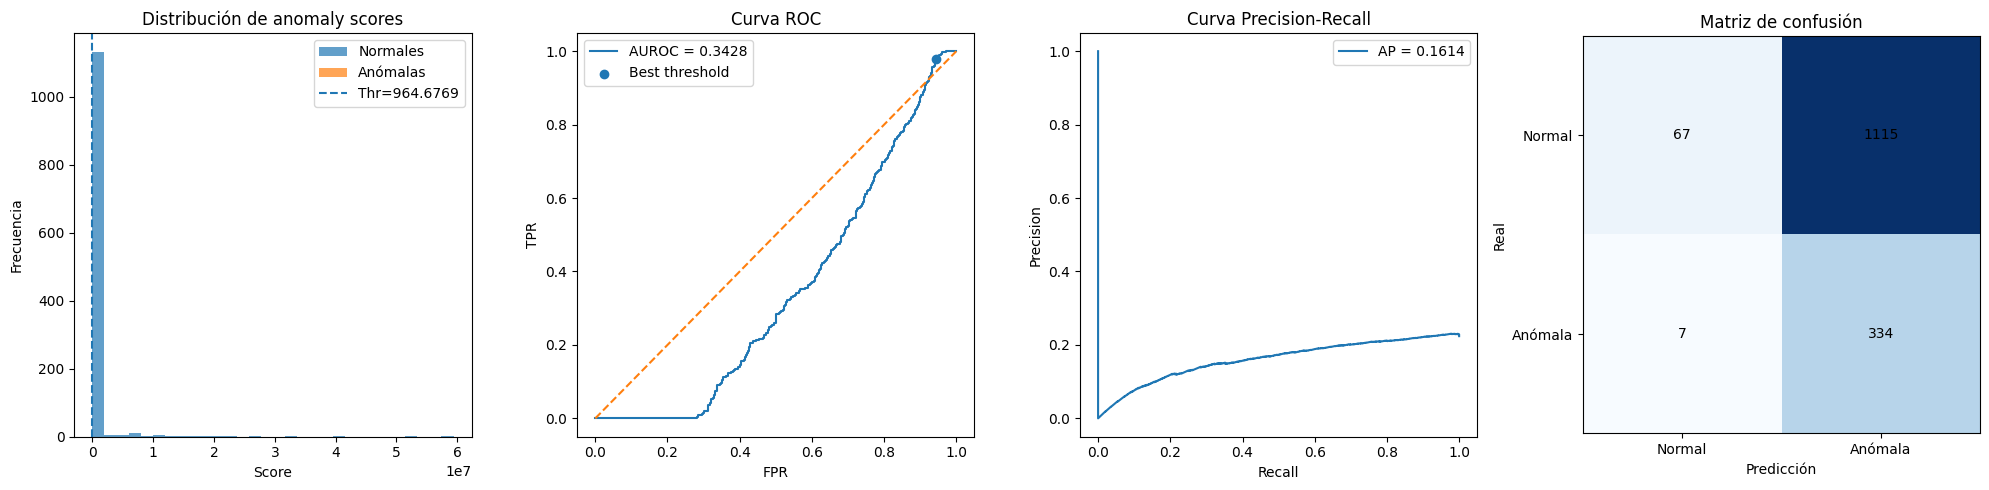

In [18]:
plt.figure(figsize=(20, 5))

# Histograma de scores
plt.subplot(1, 4, 1)
plt.hist(all_scores[all_labels == 0], bins=30, alpha=0.7, label="Normales")
plt.hist(all_scores[all_labels == 1], bins=30, alpha=0.7, label="Anómalas")
plt.axvline(best_threshold, linestyle="--", label=f"Thr={best_threshold:.4f}")
plt.title("Distribución de anomaly scores")
plt.xlabel("Score")
plt.ylabel("Frecuencia")
plt.legend()

# ROC
plt.subplot(1, 4, 2)
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.scatter(fpr[best_idx], tpr[best_idx], label="Best threshold")
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

# Precision-Recall
precision, recall, _ = precision_recall_curve(all_labels, all_scores)
plt.subplot(1, 4, 3)
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

# Matriz de confusión visual simple
plt.subplot(1, 4, 4)
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de confusión")
plt.xticks([0, 1], ["Normal", "Anómala"])
plt.yticks([0, 1], ["Normal", "Anómala"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.tight_layout()
plt.show()

#VISUALIZACIÓN:

Empezamos mostrando el mapa de calor que se genera para una imagen con anomália.

Imagen: /content/drive/MyDrive/datasets/Test_bearing_images/NG/2026_04_13_09_29_50_667-ng-0.jpg
Anomaly score           : 1413.685181
Threshold               : 964.676880
Predicción              : ANÓMALA
Prob. estimada anomalía : 81.71%
Prob. estimada normal   : 18.29%


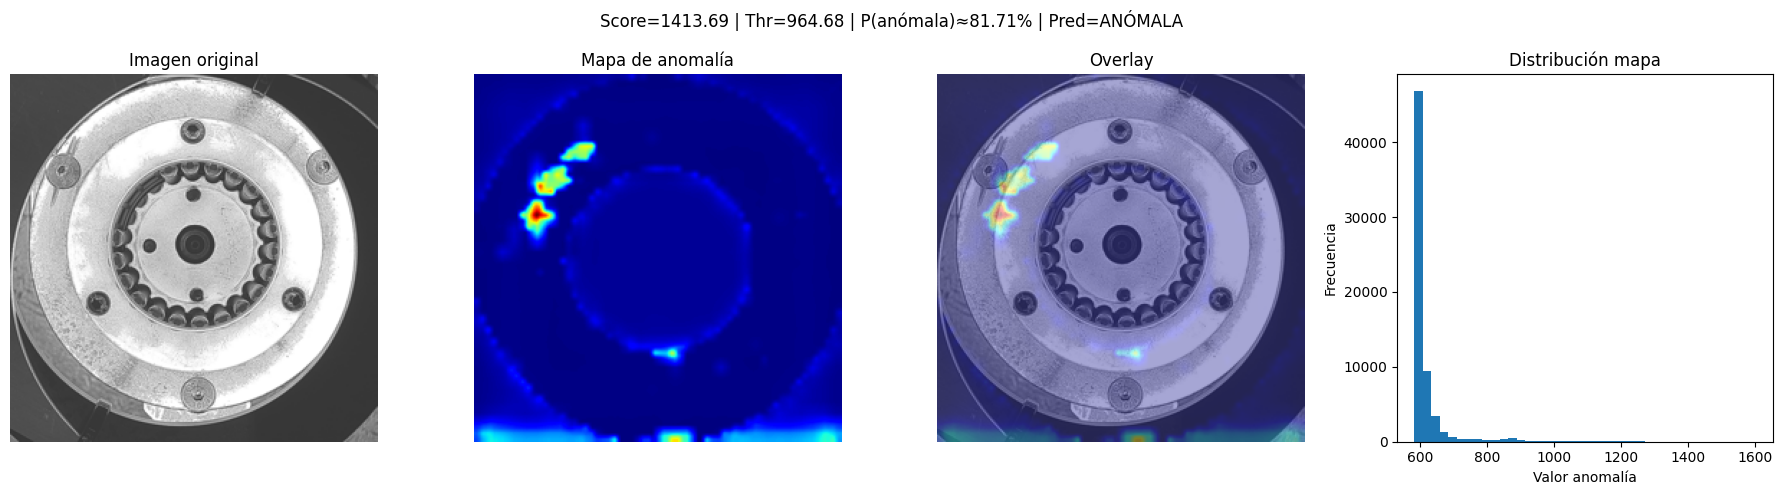

In [26]:
#ruta de la imagen concreta
IMAGE_PATH = "/content/drive/MyDrive/datasets/Test_bearing_images/NG/2026_04_13_09_29_50_667-ng-0.jpg"

# Threshold obtenido en validación
BEST_THRESHOLD = float(best_threshold)

# Temperatura para convertir score EN pseudo-probabilidad
SIGMOID_TEMP = 300.0

inference_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.crop
    ((285,225,950,900))),
    transforms.Lambda(
        lambda img: create_ring_mask(
            img,
            inner_radius=185,
            outer_radius=320
        )
    ),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# FUNCIÓN SIGMOIDE PARA PSEUDO-PROBABILIDAD
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# CARGAMOS IMAGEN
pil_img = Image.open(IMAGE_PATH).convert("RGB")
orig_w, orig_h = pil_img.size

img_tensor = inference_transform(pil_img).unsqueeze(0).to(device)

# INFERENCIA
val_model.eval()
with torch.no_grad():
    anomaly_map = val_model.anomaly_map(img_tensor, out_size=(256, 256))  # [1,1,H,W]
    anomaly_score = anomaly_map.flatten(1).topk(100, dim=1).values.mean(dim=1).item()

# MAPA DE CALOR
heatmap = anomaly_map.squeeze().cpu().numpy()

# Normalizar para visualización
heatmap_norm = heatmap - heatmap.min()
if heatmap_norm.max() > 0:
    heatmap_norm = heatmap_norm / heatmap_norm.max()

heatmap_uint8 = (heatmap_norm * 255).astype(np.uint8)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Imagen original redimensionada al tamaño del mapa
orig_np = np.array(pil_img.resize((256, 256)))

# Superposición
overlay = cv2.addWeighted(orig_np, 0.65, heatmap_color, 0.35, 0)


# PROBABILIDAD ESTIMADA
# Es una transformación suave del score respecto al threshold.
prob_anomaly = sigmoid((anomaly_score - BEST_THRESHOLD) / SIGMOID_TEMP)
prob_normal = 1.0 - prob_anomaly

pred_label = "ANÓMALA" if anomaly_score >= BEST_THRESHOLD else "NORMAL"

print(f"Imagen: {IMAGE_PATH}")
print(f"Anomaly score           : {anomaly_score:.6f}")
print(f"Threshold               : {BEST_THRESHOLD:.6f}")
print(f"Predicción              : {pred_label}")
print(f"Prob. estimada anomalía : {prob_anomaly*100:.2f}%")
print(f"Prob. estimada normal   : {prob_normal*100:.2f}%")

# MOSTRAMOS RESULTADOS
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(orig_np)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(heatmap_norm, cmap="jet")
plt.title("Mapa de anomalía")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.hist(heatmap.flatten(), bins=40)
plt.title("Distribución mapa")
plt.xlabel("Valor anomalía")
plt.ylabel("Frecuencia")

plt.suptitle(
    f"Score={anomaly_score:.2f} | Thr={BEST_THRESHOLD:.2f} | "
    f"P(anómala)≈{prob_anomaly*100:.2f}% | Pred={pred_label}",
    fontsize=12
)

plt.tight_layout()
plt.show()

Como podemos ver el modelo si que ha detectado correctamente la zona roja correspondiente a la región donde faltan rodillos en la pieza. Mostramos ahora un mapa de calor sobre dos piezas "normales" del dataset:

Imagen: /content/drive/MyDrive/datasets/Test_bearing_images/OK/2026_04_17_06_24_03_837-origin.jpg
Anomaly score           : 1003.961853
Threshold               : 964.676880
Predicción              : ANÓMALA
Prob. estimada anomalía : 53.27%
Prob. estimada normal   : 46.73%


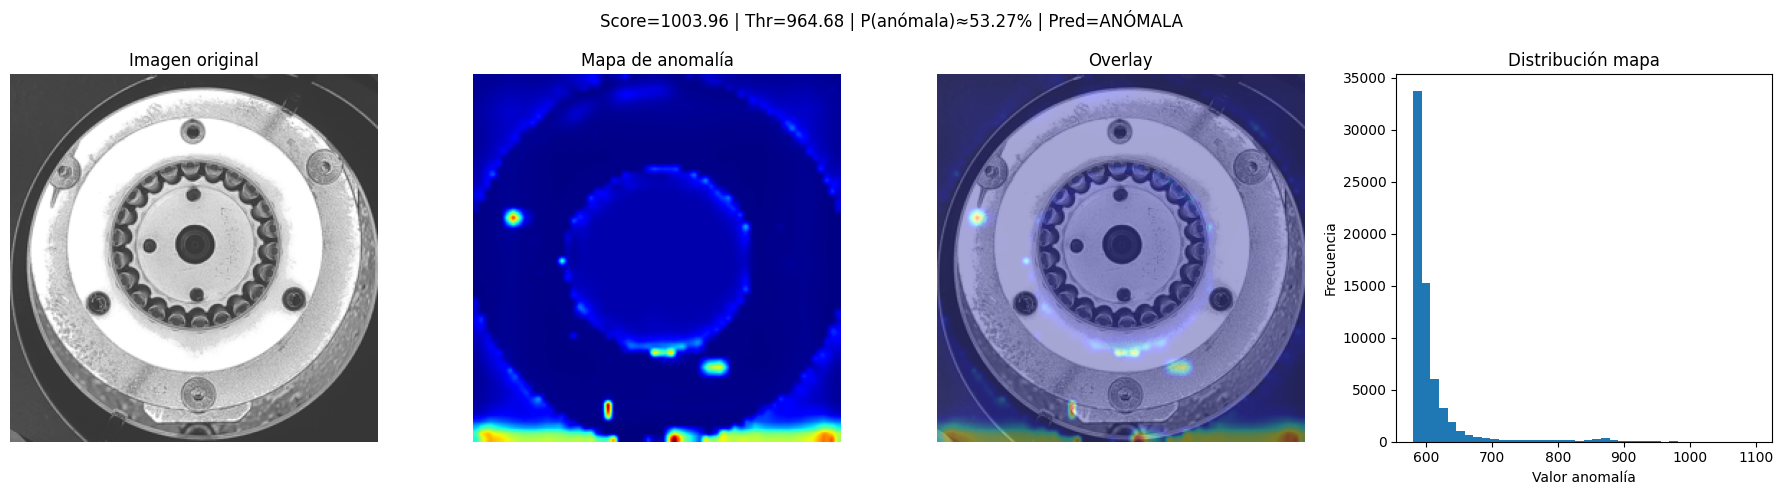

In [25]:
#ruta de la imagen concreta
IMAGE_PATH = "/content/drive/MyDrive/datasets/Test_bearing_images/OK/2026_04_17_06_24_03_837-origin.jpg"

# Threshold obtenido en validación
BEST_THRESHOLD = float(best_threshold)

# Temperatura para convertir score -> pseudo-probabilidad
SIGMOID_TEMP = 300.0

inference_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.crop((285,225,950,900))),
    transforms.Lambda(
        lambda img: create_ring_mask(
            img,
            inner_radius=185,
            outer_radius=320
        )
    ),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# FUNCIÓN SIGMOIDE PARA PSEUDO-PROBABILIDAD
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# CARGAMOS IMAGEN
pil_img = Image.open(IMAGE_PATH).convert("RGB")
orig_w, orig_h = pil_img.size

img_tensor = inference_transform(pil_img).unsqueeze(0).to(device)

# INFERENCIA
val_model.eval()
with torch.no_grad():
    anomaly_map = val_model.anomaly_map(img_tensor, out_size=(256, 256))  # [1,1,H,W]
    anomaly_score = anomaly_map.flatten(1).topk(100, dim=1).values.mean(dim=1).item()

# MAPA DE CALOR
heatmap = anomaly_map.squeeze().cpu().numpy()

# Normalizar para visualización
heatmap_norm = heatmap - heatmap.min()
if heatmap_norm.max() > 0:
    heatmap_norm = heatmap_norm / heatmap_norm.max()

heatmap_uint8 = (heatmap_norm * 255).astype(np.uint8)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Imagen original redimensionada al tamaño del mapa
orig_np = np.array(pil_img.resize((256, 256)))

# Superposición
overlay = cv2.addWeighted(orig_np, 0.65, heatmap_color, 0.35, 0)


# PROBABILIDAD ESTIMADA
# Es una transformación suave del score respecto al threshold.
prob_anomaly = sigmoid((anomaly_score - BEST_THRESHOLD) / SIGMOID_TEMP)
prob_normal = 1.0 - prob_anomaly

pred_label = "ANÓMALA" if anomaly_score >= BEST_THRESHOLD else "NORMAL"

print(f"Imagen: {IMAGE_PATH}")
print(f"Anomaly score           : {anomaly_score:.6f}")
print(f"Threshold               : {BEST_THRESHOLD:.6f}")
print(f"Predicción              : {pred_label}")
print(f"Prob. estimada anomalía : {prob_anomaly*100:.2f}%")
print(f"Prob. estimada normal   : {prob_normal*100:.2f}%")

# MOSTRAMOS RESULTADOS
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(orig_np)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(heatmap_norm, cmap="jet")
plt.title("Mapa de anomalía")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.hist(heatmap.flatten(), bins=40)
plt.title("Distribución mapa")
plt.xlabel("Valor anomalía")
plt.ylabel("Frecuencia")

plt.suptitle(
    f"Score={anomaly_score:.2f} | Thr={BEST_THRESHOLD:.2f} | "
    f"P(anómala)≈{prob_anomaly*100:.2f}% | Pred={pred_label}",
    fontsize=12
)

plt.tight_layout()
plt.show()

In [23]:
def create_ring_mask(image, inner_radius=120, outer_radius=300):

    img_np = np.array(image)

    h, w = img_np.shape[:2]

    center_x, center_y = w // 2, h // 2

    Y, X = np.ogrid[:h, :w]

    dist_from_center = np.sqrt(
        (X - center_x) ** 2 +
        (Y - center_y) ** 2
    )

    mask = (
        (dist_from_center >= inner_radius) &
        (dist_from_center <= outer_radius)
    )

    masked = np.zeros_like(img_np)

    masked[mask] = img_np[mask]

    return Image.fromarray(masked)

Imagen: /content/drive/MyDrive/datasets/Test_bearing_images/OK/2026_04_17_06_15_50_142-origin.jpg
Anomaly score           : 973.402039
Threshold               : 964.676880
Predicción              : ANÓMALA
Prob. estimada anomalía : 50.73%
Prob. estimada normal   : 49.27%


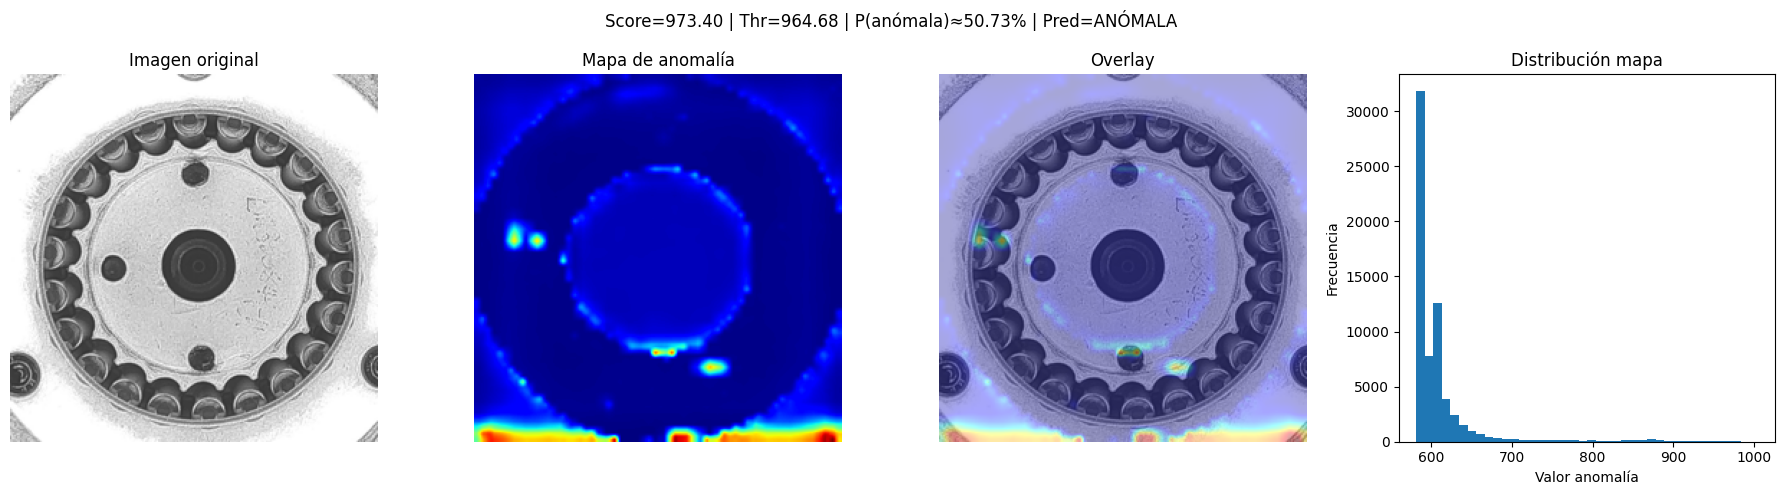

In [24]:
#ruta de la imagen concreta
IMAGE_PATH = "/content/drive/MyDrive/datasets/Test_bearing_images/OK/2026_04_17_06_15_50_142-origin.jpg"

# Threshold obtenido en validación
BEST_THRESHOLD = float(best_threshold)

# Temperatura para convertir score en pseudo-probabilidad
SIGMOID_TEMP = 300.0

inference_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.crop((285,225,950,900))),
    transforms.Lambda(
        lambda img: create_ring_mask(
            img,
            inner_radius=185,
            outer_radius=320
        )
    ),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# FUNCIÓN SIGMOIDE PARA PSEUDO-PROBABILIDAD
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# CARGAMOS IMAGEN
pil_img = Image.open(IMAGE_PATH).convert("RGB")
orig_w, orig_h = pil_img.size

img_tensor = inference_transform(pil_img).unsqueeze(0).to(device)

# INFERENCIA
val_model.eval()
with torch.no_grad():
    anomaly_map = val_model.anomaly_map(img_tensor, out_size=(256, 256))  # [1,1,H,W]
    anomaly_score = anomaly_map.flatten(1).topk(100, dim=1).values.mean(dim=1).item()

# MAPA DE CALOR
heatmap = anomaly_map.squeeze().cpu().numpy()

# Normalizar para visualización
heatmap_norm = heatmap - heatmap.min()
if heatmap_norm.max() > 0:
    heatmap_norm = heatmap_norm / heatmap_norm.max()

heatmap_uint8 = (heatmap_norm * 255).astype(np.uint8)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Imagen original redimensionada al tamaño del mapa
orig_np = np.array(pil_img.crop((285,225,950,900)).resize((256, 256)))

# Superposición
overlay = cv2.addWeighted(orig_np, 0.65, heatmap_color, 0.35, 0)


# PROBABILIDAD ESTIMADA
# Es una transformación suave del score respecto al threshold.
prob_anomaly = sigmoid((anomaly_score - BEST_THRESHOLD) / SIGMOID_TEMP)
prob_normal = 1.0 - prob_anomaly

pred_label = "ANÓMALA" if anomaly_score >= BEST_THRESHOLD else "NORMAL"

print(f"Imagen: {IMAGE_PATH}")
print(f"Anomaly score           : {anomaly_score:.6f}")
print(f"Threshold               : {BEST_THRESHOLD:.6f}")
print(f"Predicción              : {pred_label}")
print(f"Prob. estimada anomalía : {prob_anomaly*100:.2f}%")
print(f"Prob. estimada normal   : {prob_normal*100:.2f}%")

# MOSTRAMOS RESULTADOS
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(orig_np)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(heatmap_norm, cmap="jet")
plt.title("Mapa de anomalía")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.hist(heatmap.flatten(), bins=40)
plt.title("Distribución mapa")
plt.xlabel("Valor anomalía")
plt.ylabel("Frecuencia")

plt.suptitle(
    f"Score={anomaly_score:.2f} | Thr={BEST_THRESHOLD:.2f} | "
    f"P(anómala)≈{prob_anomaly*100:.2f}% | Pred={pred_label}",
    fontsize=12
)

plt.tight_layout()
plt.show()

En ambos casos la zona de los rodillos no tiene ninguna anomalía y es marcada correcta por el modelo, sin embargo las imágenes están siendo consideradas anómlas con una probabilidad que está muy ajustada.

He probado con varias imágenes buenas y en todas ellas la region de interés ha sido marcada sin anomalía. El problema de una mala clasificacion se está debiendo a que por el propio brillo del matal esta sacando una alta probabilidad de las zonas fuera de interés de que la imágen sea anómala.

REFLEXIÓN:
- El modelo me esta dando muy malas métricas, especialmente en imágenes normales porque la mayoria de imágenes están en el limbo.

- Las imágenes anómalas al tener más región anómala si que esán siendo clasificadas correctamente pero las imágenes normales solo tienen de region anomala las zonas exterior e interior de los rodillos, lo que hace que el modelo las esté clasificando al azar.

- Para solucionar este problema voy a emascarar en el preprocesamiento las zonas interiores de los rodillos y exteriores justo después de hacer el redimensionado. Con esto volveré a entrenar el modelo y veré si se obtienen mejores resultados.

Nota: por los límites de uso solo me deja entrenar un modelo por día entonces no me da tiempo a entrenarlo antes de la entrega de la RAA (he tenido muchos entrenamientos malos de modelos que no me han funcionado :( )